<a href="https://colab.research.google.com/github/wojtwkg/lecture1/blob/main/Wojciech15_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import datasets
data = datasets.load_iris()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets

In [4]:
print(data.data)
print(data.target)
data.DESCR


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [6]:
data = datasets.load_iris()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features names:", feature_names)
print("Class names:", data.target_names)

X shape: (150, 4)
y shape: (150,)
Features names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']


In [9]:
df = pd.DataFrame(data=X, columns=feature_names)
df['species'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


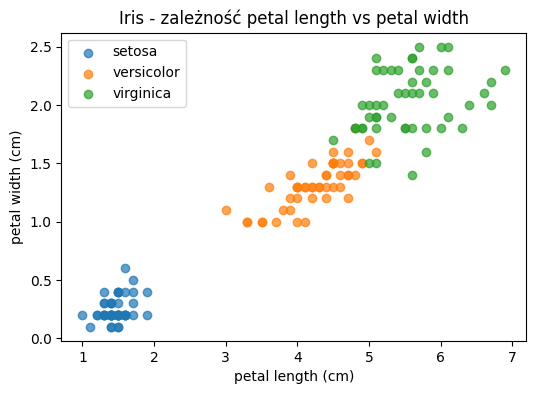

In [10]:

species_names = data.target_names


colors = ['blue','red','green']

plt.figure(figsize=(6,4))
for i, species in enumerate(np.unique(y)):
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species_names[species],
        alpha=0.7
    )

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Iris - zależność petal length vs petal width")
plt.legend()
plt.show()

In [11]:
def entropy(labels):
    """
    Oblicza entropię zbioru na podstawie etykiet klas (labels).
    """

    _, counts = np.unique(labels, return_counts=True)

    # Prawdopodobieństwa
    p = counts / counts.sum()

    # Entropia
    return -np.sum(p * np.log2(p))

In [12]:
def information_gain_for_split(feature_values, labels, threshold):
    """
    Zwraca (information_gain, entropy_left, entropy_right) dla podziału:
        feature_values <= threshold
        vs
        feature_values > threshold
    """
    # Entropia całego zbioru
    H_before = entropy(labels)


    left_indices = feature_values <= threshold
    right_indices = feature_values > threshold


    H_left = entropy(labels[left_indices])

    H_right = entropy(labels[right_indices])


    n_left = sum(left_indices)
    n_right = sum(right_indices)
    n_total = len(labels)


    H_after = (n_left/n_total)*H_left + (n_right/n_total)*H_right


    IG = H_before - H_after

    return IG, H_left, H_right

In [13]:
feature_values = X[:, 3]
labels = y

thresholds = [1.5, 0.38]

for th in thresholds:
    IG, H_left, H_right = information_gain_for_split(feature_values, labels, th)
    print(f"Threshold: {th}")
    print(f"  IG = {IG:.4f}, Entropy left = {H_left:.4f}, Entropy right = {H_right:.4f}\n")

Threshold: 1.5
  IG = 0.6656, Entropy left = 1.1649, Entropy right = 0.4567

Threshold: 0.38
  IG = 0.6195, Entropy left = -0.0000, Entropy right = 1.3286



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [16]:
decision_tree = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [17]:
y_pred_tree = decision_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy (Decision Tree): {accuracy_tree:.4f}")

Accuracy (Decision Tree): 0.8889


In [18]:
random_forest = RandomForestClassifier(
    n_estimators=15,
    criterion='entropy',
    random_state=42
)
random_forest.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=15, random_state=42)

In [19]:
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")

Accuracy (Random Forest): 0.9111


Accuracy na zbiorze testowym: 0.9333


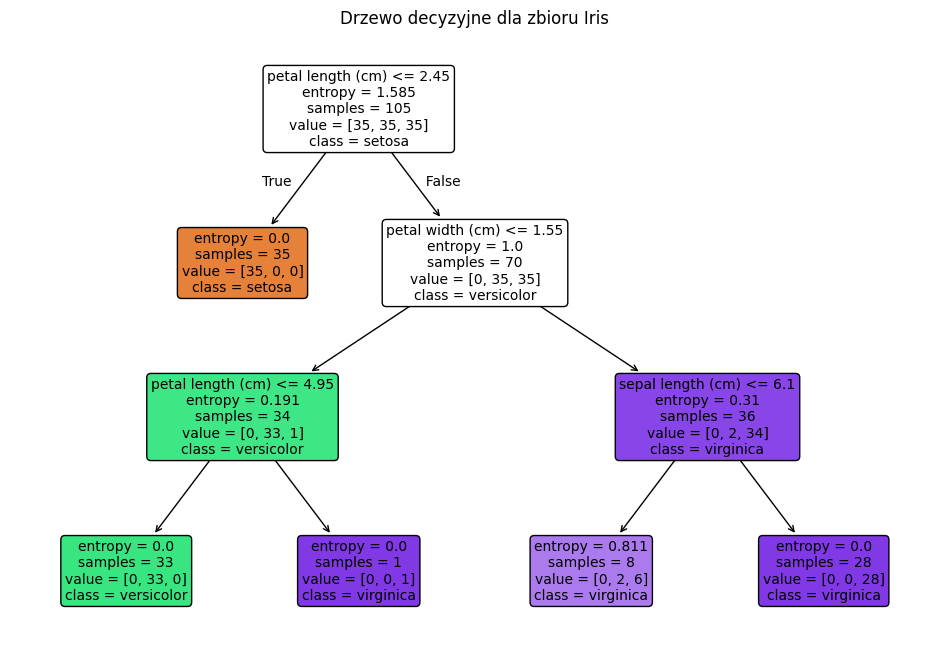

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


%matplotlib inline


iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


decision_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)
decision_tree.fit(X_train, y_train)


y_pred = decision_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy na zbiorze testowym: {accuracy:.4f}")


plt.figure(figsize=(12, 8))
plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Drzewo decyzyjne dla zbioru Iris")
plt.show()

In [24]:
import seaborn as sns

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.bar(indices, importances)
plt.xticks(indices, feature_names, rotation=45)
plt.title("Ważność cech - Random Forest")
plt.xlabel("Cecha")
plt.ylabel("Ważność")
plt.tight_layout()
plt.show()

NameError: name 'indices' is not defined

<Figure size 800x500 with 0 Axes>